
--- Iteration 1 Summary ---
Best cost: 68589.67, Avg: 78747.19, Std: 4936.42
Unique tours: 50, Strong clusters: 1100, Weak clusters: 195
  Ocean   best cost 78716.58, tour [27, 26, 23, 0, 5, 1, 11, 6, 10, 22, 20, 21, 28, 14, 16, 2, 19, 8, 13, 25, 7, 3, 4, 9, 18, 12, 15, 17, 24]
  Memory  best cost 72812.95, tour [27, 26, 23, 0, 5, 1, 18, 6, 10, 22, 20, 21, 28, 14, 16, 2, 19, 25, 13, 8, 7, 3, 4, 9, 11, 12, 15, 17, 24]
  ACMM    best cost 68656.33, tour [27, 26, 0, 5, 1, 6, 10, 22, 20, 21, 28, 14, 16, 2, 19, 13, 8, 7, 3, 4, 9, 11, 12, 18, 25, 23, 15, 17, 24]
  MFBO    best cost 68589.67, tour [7, 18, 0, 1, 5, 10, 9, 3, 28, 23, 24, 26, 21, 17, 16, 8, 2, 19, 20, 15, 22, 25, 27, 4, 6, 11, 14, 13, 12]
  CMA     best cost 68589.67, tour [7, 18, 0, 1, 5, 10, 9, 3, 28, 23, 24, 26, 21, 17, 16, 8, 2, 19, 20, 15, 22, 25, 27, 4, 6, 11, 14, 13, 12]

--- Iteration 100 Summary ---
Best cost: 44122.39, Avg: 57420.12, Std: 6168.82
Unique tours: 50, Strong clusters: 11674, Weak clusters: 2123
  Ocean   

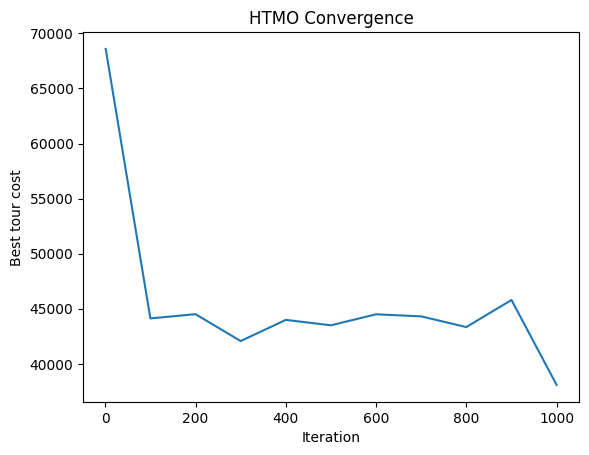


Final best tour: [4, 3, 9, 10, 11, 13, 19, 25, 24, 15, 23, 26, 27, 17, 14, 18, 22, 21, 28, 20, 16, 12, 6, 7, 2, 8, 0, 1, 5]
Final tour cost: 38083.24780273505


In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from math import sqrt
from itertools import combinations

# ----------------------
# 1. TSPLIB Parsing & Distance Matrix
# ----------------------

def parse_tsplib(filename: str) -> np.ndarray:
    coords = {}
    with open(filename, 'r') as f:
        in_section = False
        for line in f:
            line = line.strip()
            if line == "NODE_COORD_SECTION":
                in_section = True
                continue
            if in_section:
                if line == "EOF":
                    break
                parts = line.split()
                idx = int(parts[0]) - 1
                x, y = float(parts[1]), float(parts[2])
                coords[idx] = (x, y)
    n = len(coords)
    arr = np.zeros((n, 2))
    for i in range(n):
        arr[i] = coords[i]
    return arr

def euclidean_distance_matrix(coords: np.ndarray) -> np.ndarray:
    n = coords.shape[0]
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dx, dy = coords[i] - coords[j]
            dist[i, j] = sqrt(dx*dx + dy*dy)
    return dist

# ----------------------
# 2. Utility Functions
# ----------------------

def total_distance(tour: list, dist_matrix: np.ndarray) -> float:
    n = len(tour)
    return sum(dist_matrix[tour[i], tour[(i + 1) % n]] for i in range(n))

def initialize_population(n_cities: int, pop_size: int) -> list:
    population = []
    for _ in range(pop_size):
        tour = list(range(n_cities))
        random.shuffle(tour)
        population.append(tour)
    return population

# ----------------------
# 3. Fitness-Aware Turtle Operators
# ----------------------

def ocean_current_drift(tour: list,
                        dist_matrix: np.ndarray,
                        swap_prob: float = 0.2,
                        num_candidates: int = 5) -> list:
    candidates = []
    for _ in range(num_candidates):
        new_t = tour.copy()
        for i in range(len(tour)):
            if random.random() < swap_prob:
                j = random.randrange(len(tour))
                new_t[i], new_t[j] = new_t[j], new_t[i]
        candidates.append(new_t)
    candidates.append(tour)
    return min(candidates, key=lambda t: total_distance(t, dist_matrix))

def memory_aware_drift(base_tour: list,
                       cluster_memory: dict,
                       dist_matrix: np.ndarray,
                       max_attempts: int = 10) -> list:
    valid = []
    for _ in range(max_attempts):
        candidate = ocean_current_drift(base_tour, dist_matrix)
        bad = False
        for cluster in cluster_memory['weak']:
            size = len(cluster)
            for i in range(len(candidate) - size + 1):
                if tuple(candidate[i:i+size]) == cluster:
                    bad = True
                    break
            if bad:
                break
        if not bad:
            valid.append(candidate)
    valid.append(base_tour)
    return min(valid, key=lambda t: total_distance(t, dist_matrix))

def ACMM_operator(tour: list,
                  cluster_memory: dict,
                  dist_matrix: np.ndarray,
                  cluster_size: int = 3,
                  num_candidates: int = 5) -> tuple:
    avg_inv = cluster_size * (1.0 / np.mean(dist_matrix[np.nonzero(dist_matrix)]))
    for i in range(len(tour) - cluster_size + 1):
        cluster = tuple(tour[i:i+cluster_size])
        strength = sum(
            (1.0 / dist_matrix[a, b])
            for a, b in combinations(cluster, 2)
            if dist_matrix[a, b] > 0
        )
        if strength >= avg_inv:
            cluster_memory['strong'].add(cluster)
        else:
            cluster_memory['weak'].add(cluster)

    candidates = []
    strong = list(cluster_memory['strong'])
    for _ in range(num_candidates):
        new_t = tour.copy()
        if strong:
            cl = random.choice(strong)
            for c in cl:
                new_t.remove(c)
            pos = random.randrange(len(new_t) + 1)
            for offset, c in enumerate(cl):
                new_t.insert(pos + offset, c)
        candidates.append(new_t)
    candidates.append(tour)

    best_t = min(candidates, key=lambda t: total_distance(t, dist_matrix))
    return best_t, cluster_memory

def MFBO(tour: list,
         dist_matrix: np.ndarray,
         k_neighbors: int = 5,
         alpha: float = 1.0) -> list:
    current_cost = total_distance(tour, dist_matrix)
    best_tour = tour
    best_strength = -1.0
    MAX_EXP_ARG = 700
    for _ in range(k_neighbors):
        i, j = sorted(random.sample(range(len(tour)), 2))
        neighbor = tour[:i] + tour[i:j+1][::-1] + tour[j+1:]
        delta = total_distance(neighbor, dist_matrix) - current_cost
        arg = -alpha * delta
        if arg > MAX_EXP_ARG:
            strength = float('inf')
        elif arg < -MAX_EXP_ARG:
            strength = 0.0
        else:
            strength = math.exp(arg)
        if strength > best_strength:
            best_strength = strength
            best_tour = neighbor
    return best_tour

def CMA(tour: list,
        elite_tours: list,
        subpath_len: int = 3) -> list:
    counts = {}
    for elite in elite_tours:
        for i in range(len(elite) - subpath_len + 1):
            sub = tuple(elite[i:i+subpath_len])
            counts[sub] = counts.get(sub, 0) + 1
    if not counts:
        return tour
    best_sub = max(counts, key=counts.get)
    seq = tour.copy()
    if all(city in seq for city in best_sub):
        start = seq.index(best_sub[0])
        for c in best_sub:
            seq.remove(c)
        for offset, c in enumerate(best_sub):
            seq.insert(start + offset, c)
    return seq

def update_elite(population: list,
                 dist_matrix: np.ndarray,
                 elite_size: int = 3) -> list:
    sorted_pop = sorted(population, key=lambda t: total_distance(t, dist_matrix))
    return sorted_pop[:elite_size]

# ----------------------
# 4. HTMO Final Main Loop with Metrics & Logging
# ----------------------

def HTMO_Final(dist_matrix: np.ndarray,
               pop_size: int = 30,
               iterations: int = 500,
               log_interval: int = 100) -> tuple:
    n = dist_matrix.shape[0]
    population = initialize_population(n, pop_size)
    elite_memory = []
    cluster_memory = {'strong': set(), 'weak': set()}

    # metrics storage
    history_iters = []
    history_best = []
    history_avg = []
    history_std = []
    history_unique = []
    history_strong = []
    history_weak = []

    for it in range(1, iterations + 1):
        # apply each operator stage-wise
        pop1 = [ocean_current_drift(t, dist_matrix) for t in population]
        pop2 = [memory_aware_drift(t, cluster_memory, dist_matrix) for t in pop1]
        pop3 = []
        for t in pop2:
            t2, cluster_memory = ACMM_operator(t, cluster_memory, dist_matrix)
            pop3.append(t2)
        pop4 = [MFBO(t, dist_matrix) for t in pop3]
        pop5 = [CMA(t, elite_memory) for t in pop4]

        population = pop5
        elite_memory = update_elite(population, dist_matrix)

        # logging every log_interval iterations
        if it % log_interval == 0 or it == 1:
            # compute population costs
            costs = [total_distance(t, dist_matrix) for t in population]
            best_cost = min(costs)
            avg_cost = sum(costs) / len(costs)
            std_cost = np.std(costs)
            unique_count = len({tuple(t) for t in population})
            strong_count = len(cluster_memory['strong'])
            weak_count = len(cluster_memory['weak'])

            history_iters.append(it)
            history_best.append(best_cost)
            history_avg.append(avg_cost)
            history_std.append(std_cost)
            history_unique.append(unique_count)
            history_strong.append(strong_count)
            history_weak.append(weak_count)

            print(f"\n--- Iteration {it} Summary ---")
            print(f"Best cost: {best_cost:.2f}, Avg: {avg_cost:.2f}, Std: {std_cost:.2f}")
            print(f"Unique tours: {unique_count}, Strong clusters: {strong_count}, Weak clusters: {weak_count}")
            # best tours at each stage
            stages = {'Ocean': pop1, 'Memory': pop2, 'ACMM': pop3, 'MFBO': pop4, 'CMA': pop5}
            for name, pop in stages.items():
                c = [total_distance(t, dist_matrix) for t in pop]
                bt = pop[c.index(min(c))]
                print(f"  {name:7s} best cost {min(c):.2f}, tour {bt}")

        # continue to next iteration

    # plot convergence
    plt.figure()
    plt.plot(history_iters, history_best)
    plt.xlabel('Iteration')
    plt.ylabel('Best tour cost')
    plt.title('HTMO Convergence')
    plt.show()

    best_tour = elite_memory[0]
    return best_tour, total_distance(best_tour, dist_matrix)

# ----------------------
# 5. Example Usage
# ----------------------

if __name__ == "__main__":
    tsp_file = '/wi290.tsp'
    coords = parse_tsplib(tsp_file)
    dist_matrix = euclidean_distance_matrix(coords)

    best, cost = HTMO_Final(dist_matrix,
                             pop_size=50,
                             iterations=1000,
                             log_interval=100)
    print("\nFinal best tour:", best)
    print("Final tour cost:", cost)
